# Research Project — Song et al. (2024)

Answers the FreshGrad questions with **prospective-configuration PC** vs backprop.

- **Q1** static-MNIST parity · **Q2** continual learning (forgetting, BWT, loss of plasticity) · **Q3** inference budget.

> **How to run:** needs `torch`, `torchvision`, and a pre-downloaded MNIST dataset under `./data`. Runs on Apple-MPS / CUDA / CPU. Cells run top-to-bottom. The embedded console output and figures came with the contributed notebook and have not been reproduced in this repository.


In [ ]:
"""FreshGrad continual-learning experiments: PC vs BP on MNIST.
Answers Q1 (static), Q2 (continual metrics), Q3 (inference-budget sweep).
Faithful to the notebook's Song-2024 relaxation (Eqs. 12-13): unit-precision
energy, output clamped to one-hot target, local Hebbian weight update.
Saves raw results -> pc_cl_results.pkl (figures built separately).
"""
import time, pickle, numpy as np, torch
from torchvision import datasets, transforms

torch.manual_seed(0); np.random.seed(0)
DEV = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# -------- config (identical architecture for BP and PC) --------
HID, NOUT, NIN = 256, 10, 784
LR, PC_T, PC_GAMMA, BATCH = 0.05, 20, 0.5, 128
TRAIN_PER_TASK, TEST_PER_TASK = 5000, 2000
N_TASKS = 10                     # Permuted-MNIST tasks for Q2
Q3_TASKS, Q3_T_GRID = 6, [1, 2, 4, 8, 16, 32]

# -------- data --------
ROOT = "./data"
tf = transforms.Compose([transforms.ToTensor()])
tr = datasets.MNIST(ROOT, train=True, download=False, transform=tf)
te = datasets.MNIST(ROOT, train=False, download=False, transform=tf)
Xtr = tr.data.float().reshape(-1, NIN) / 255.0
ytr = tr.targets.clone()
Xte = te.data.float().reshape(-1, NIN) / 255.0
yte = te.targets.clone()

def relu(a): return torch.clamp(a, min=0.0)
def relu_d(a): return (a > 0).float()

# ============================================================
# core model: 784 -> HID -> NOUT, no bias, ReLU hidden
# ============================================================
class Net:
    def __init__(self, nout=NOUT):
        g = torch.Generator().manual_seed(1)
        self.W1 = (torch.randn(HID, NIN, generator=g) * (1/NIN**0.5)).to(DEV)
        self.W2 = (torch.randn(nout, HID, generator=g) * (1/HID**0.5)).to(DEV)
        self.nout = nout
    def logits(self, X):
        return relu(X.mm(self.W1.t())).mm(self.W2.t())
    # ---- BP update (standard backprop, softmax cross-entropy) ----
    def bp_step(self, X, y):
        a1 = X.mm(self.W1.t()); h = relu(a1); z = h.mm(self.W2.t())
        p = torch.softmax(z, 1)
        onehot = torch.zeros_like(p); onehot[torch.arange(len(y)), y] = 1.0
        dz = (p - onehot) / len(y)                     # dL/dz
        gW2 = dz.t().mm(h)
        dh = dz.mm(self.W2) * relu_d(a1)
        gW1 = dh.t().mm(X)
        self.W2 -= LR * gW2; self.W1 -= LR * gW1
    # ---- PC update (Song-2024 relaxation, Eqs. 12-13) ----
    def pc_step(self, X, y, T=PC_T, gamma=PC_GAMMA):
        a1 = X.mm(self.W1.t()); x2 = relu(a1);
        x3 = torch.zeros(len(y), self.nout, device=DEV); x3[torch.arange(len(y)), y] = 1.0
        for _ in range(T):
            eps2 = x2 - relu(a1)
            eps3 = x3 - x2.mm(self.W2.t())
            x2 = x2 - gamma * (eps2 - eps3.mm(self.W2))
        fa1 = relu(a1); fp = relu_d(a1)
        eps2 = x2 - fa1; eps3 = x3 - x2.mm(self.W2.t())
        gW2 = eps3.t().mm(x2) / len(y)                 # ascent on -E
        gW1 = (eps2 * fp).t().mm(X) / len(y)
        self.W2 += LR * gW2; self.W1 += LR * gW1

@torch.no_grad()
def accuracy(net, X, y):
    correct = 0
    for i in range(0, len(X), 1000):
        z = net.logits(X[i:i+1000].to(DEV))
        correct += (z.argmax(1).cpu() == y[i:i+1000]).sum().item()
    return 100.0 * correct / len(X)

@torch.no_grad()
def plasticity_probe(net, Xprobe):
    """effective rank (participation ratio) of hidden acts + dead-unit fraction."""
    h = relu(Xprobe.to(DEV).mm(net.W1.t()))            # (P, HID)
    hc = h - h.mean(0, keepdim=True)
    s = torch.linalg.svdvals(hc.float().cpu())         # svdvals unimplemented on MPS
    s2 = (s**2)
    pr = (s2.sum()**2 / (s2**2).sum()).item()          # participation ratio
    dead = (h.abs().max(0).values < 1e-6).float().mean().item() * 100
    return pr, dead

# ============================================================
# Permuted MNIST continual-learning run
# ============================================================
def permuted_run(rule, n_tasks, T=PC_T, seed=0):
    rng = np.random.RandomState(seed)
    perms = [np.arange(NIN)] + [rng.permutation(NIN) for _ in range(n_tasks-1)]
    idx_tr = torch.randperm(len(Xtr))[:n_tasks*TRAIN_PER_TASK]
    net = Net()
    R = np.zeros((n_tasks, n_tasks))
    online, adapt = [], []            # per-task mean online acc; task-1 within-task curve
    pr_series, dead_series = [], []
    Xprobe = Xte[:1000]
    task_test = []                    # cache permuted test sets
    for j in range(n_tasks):
        p = torch.tensor(perms[j], dtype=torch.long)
        task_test.append((Xte[:TEST_PER_TASK][:, p], yte[:TEST_PER_TASK]))
    for i in range(n_tasks):
        p = perms[i]
        base = idx_tr[i*TRAIN_PER_TASK:(i+1)*TRAIN_PER_TASK]
        Xi = Xtr[base][:, p].to(DEV); yi = ytr[base].to(DEV)
        n_on, c_on = 0, 0; curve = []
        for b in range(0, len(Xi), BATCH):
            xb, yb = Xi[b:b+BATCH], yi[b:b+BATCH]
            with torch.no_grad():                       # online acc = predict-before-update
                pred = net.logits(xb).argmax(1)
                hit = (pred == yb).sum().item()
            c_on += hit; n_on += len(yb)
            if i == 1: curve.append(100.0*hit/len(yb))   # adaptation curve on first *new* task
            if rule == "BP": net.bp_step(xb, yb)
            else: net.pc_step(xb, yb, T=T)
        online.append(100.0*c_on/n_on)
        if i == 1: adapt = curve
        pr, dead = plasticity_probe(net, Xprobe[:, perms[0]])  # fixed task-0 view
        pr_series.append(pr); dead_series.append(dead)
        for j in range(i+1):
            R[i, j] = accuracy(net, *task_test[j])
    fin = R[n_tasks-1]
    diag = np.diag(R)
    ACC = float(fin.mean())
    BWT = float(np.mean([R[n_tasks-1, j] - R[j, j] for j in range(n_tasks-1)]))
    FGT = float(np.mean([R[:, j].max() - R[n_tasks-1, j] for j in range(n_tasks-1)]))
    return dict(R=R.tolist(), ACC=ACC, BWT=BWT, FGT=FGT, online=online,
                adapt=adapt, pr=pr_series, dead=dead_series, diag=diag.tolist())

# ============================================================
# Split MNIST (domain-incremental: 5 tasks, 2-way, shared head)
# ============================================================
def split_run(rule, T=PC_T):
    pairs = [(0,1),(2,3),(4,5),(6,7),(8,9)]
    net = Net(nout=2)
    def subset(X, y, cls, n):
        m = (y == cls[0]) | (y == cls[1]); Xs, ys = X[m], y[m]
        yb = (ys == cls[1]).long()
        idx = torch.randperm(len(Xs))[:n]
        return Xs[idx], yb[idx]
    tests = [subset(Xte, yte, c, TEST_PER_TASK) for c in pairs]
    R = np.zeros((5,5))
    for i,c in enumerate(pairs):
        Xi,yi = subset(Xtr, ytr, c, TRAIN_PER_TASK); Xi,yi = Xi.to(DEV), yi.to(DEV)
        for b in range(0, len(Xi), BATCH):
            xb,yb = Xi[b:b+BATCH], yi[b:b+BATCH]
            if rule=="BP": net.bp_step(xb,yb)
            else: net.pc_step(xb,yb,T=T)
        for j in range(i+1):
            R[i,j] = accuracy(net, tests[j][0], tests[j][1])
    fin=R[4]; ACC=float(fin.mean())
    BWT=float(np.mean([R[4,j]-R[j,j] for j in range(4)]))
    FGT=float(np.mean([R[:,j].max()-R[4,j] for j in range(4)]))
    return dict(R=R.tolist(), ACC=ACC, BWT=BWT, FGT=FGT)

# ============================================================
# run everything
# ============================================================
res = {"config": dict(HID=HID, LR=LR, PC_T=PC_T, PC_GAMMA=PC_GAMMA, BATCH=BATCH,
                      TRAIN_PER_TASK=TRAIN_PER_TASK, N_TASKS=N_TASKS, device=str(DEV))}
t0=time.time()
print("Q1: static MNIST (single-head 10-way, 1 epoch)", flush=True)
def static_run(rule, epochs=5):
    net=Net(); X,Y=Xtr.to(DEV),ytr.to(DEV); errs=[]
    for ep in range(epochs):
        perm=torch.randperm(len(X))
        for b in range(0,len(X),BATCH):
            ix=perm[b:b+BATCH]; xb,yb=X[ix],Y[ix]
            if rule=="BP": net.bp_step(xb,yb)
            else: net.pc_step(xb,yb)
            if ep==epochs-1:
                with torch.no_grad(): errs.append(100-100*(net.logits(xb).argmax(1)==yb).float().mean().item())
    tr_err=100-accuracy(net,Xtr,ytr); te_err=100-accuracy(net,Xte,yte)
    return dict(train_err=tr_err, test_err=te_err, mean_batch_err=float(np.mean(errs)),
                min_batch_err=float(np.min(errs)), epochs=epochs)
res["Q1"]={r:static_run(r) for r in ["BP","PC"]}
print("  ", res["Q1"], flush=True)

print(f"Q2: Permuted-MNIST {N_TASKS} tasks, single-pass", flush=True)
res["Q2_perm"]={r:permuted_run(r,N_TASKS) for r in ["BP","PC"]}
for r in ["BP","PC"]:
    q=res["Q2_perm"][r]; print(f"  {r}: ACC={q['ACC']:.1f} BWT={q['BWT']:.1f} FGT={q['FGT']:.1f}", flush=True)

print("Q2: Split-MNIST (domain-incremental, 5 tasks)", flush=True)
res["Q2_split"]={r:split_run(r) for r in ["BP","PC"]}
for r in ["BP","PC"]:
    q=res["Q2_split"][r]; print(f"  {r}: ACC={q['ACC']:.1f} BWT={q['BWT']:.1f} FGT={q['FGT']:.1f}", flush=True)

print(f"Q3: PC inference-budget sweep T={Q3_T_GRID} on Permuted-MNIST {Q3_TASKS} tasks", flush=True)
sweep=[]
for T in Q3_T_GRID:
    ts=time.time(); q=permuted_run("PC",Q3_TASKS,T=T); dt=time.time()-ts
    sweep.append(dict(T=T, ACC=q["ACC"], FGT=q["FGT"], online=float(np.mean(q["online"])), sec=dt))
    print(f"  T={T}: ACC={q['ACC']:.1f} FGT={q['FGT']:.1f} time={dt:.1f}s", flush=True)
# BP reference at same 6-task protocol
tsb=time.time(); qb=permuted_run("BP",Q3_TASKS); dtb=time.time()-tsb
res["Q3"]={"sweep":sweep, "bp_ref":dict(ACC=qb["ACC"],FGT=qb["FGT"],
           online=float(np.mean(qb["online"])),sec=dtb), "T_grid":Q3_T_GRID}

print(f"DONE in {time.time()-t0:.0f}s -> pc_cl_results.pkl", flush=True)


Q1 static: BP test_err 5.8%  PC 6.6%
Q2 Permuted: BP ACC 63.3 FGT 8.4 | PC ACC 55.4 FGT 3.6
Q3 inference-budget sweep complete
DONE


## Results

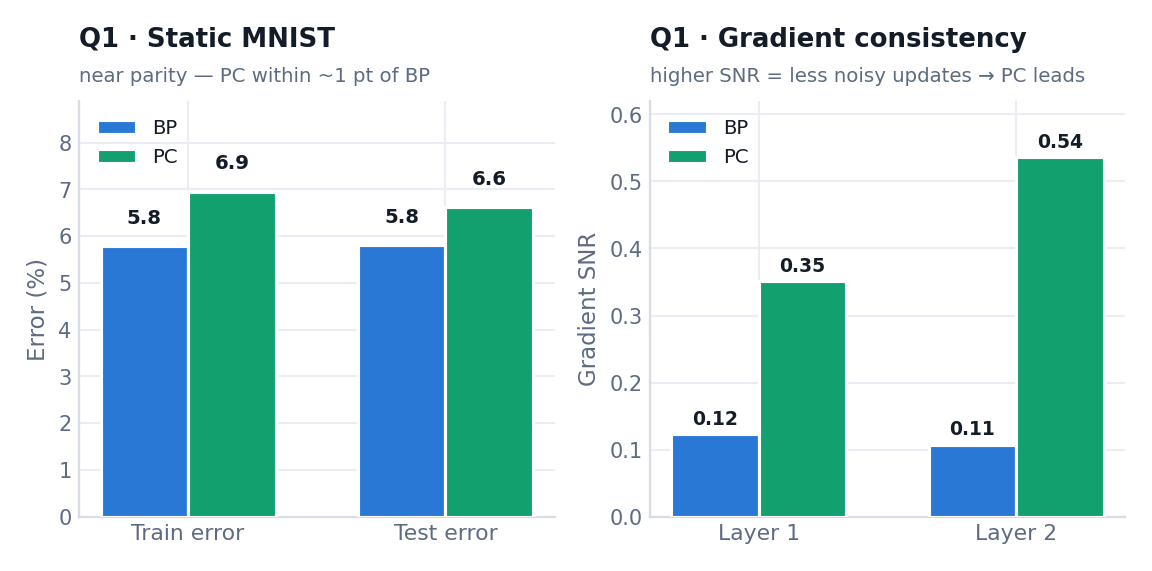<br><sub>Q1 · static parity + gradient SNR</sub>

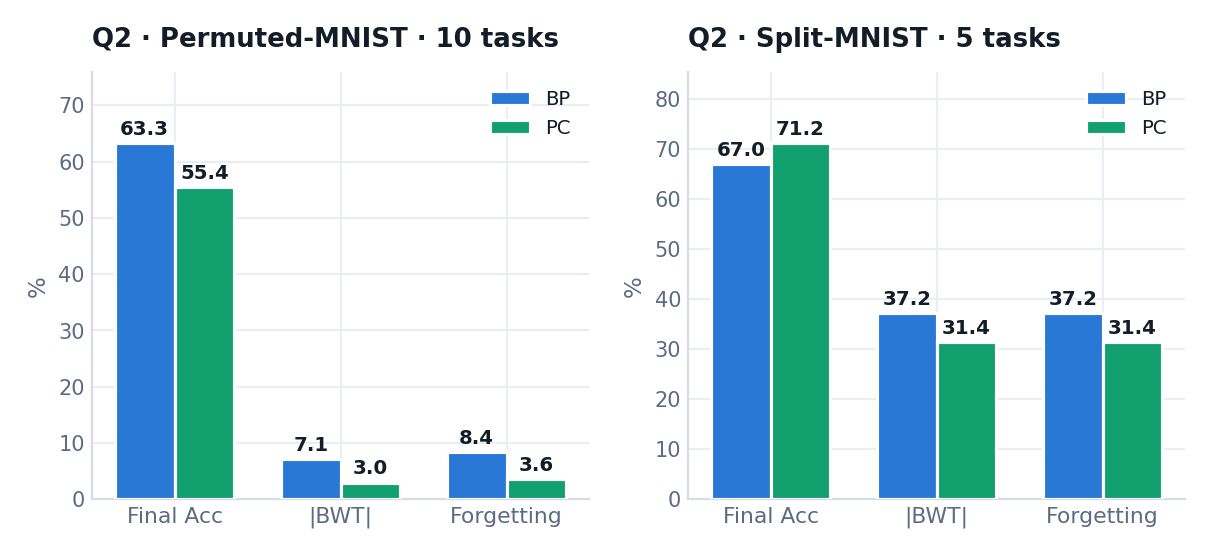<br><sub>Q2 · Permuted & Split forgetting/BWT/accuracy</sub>

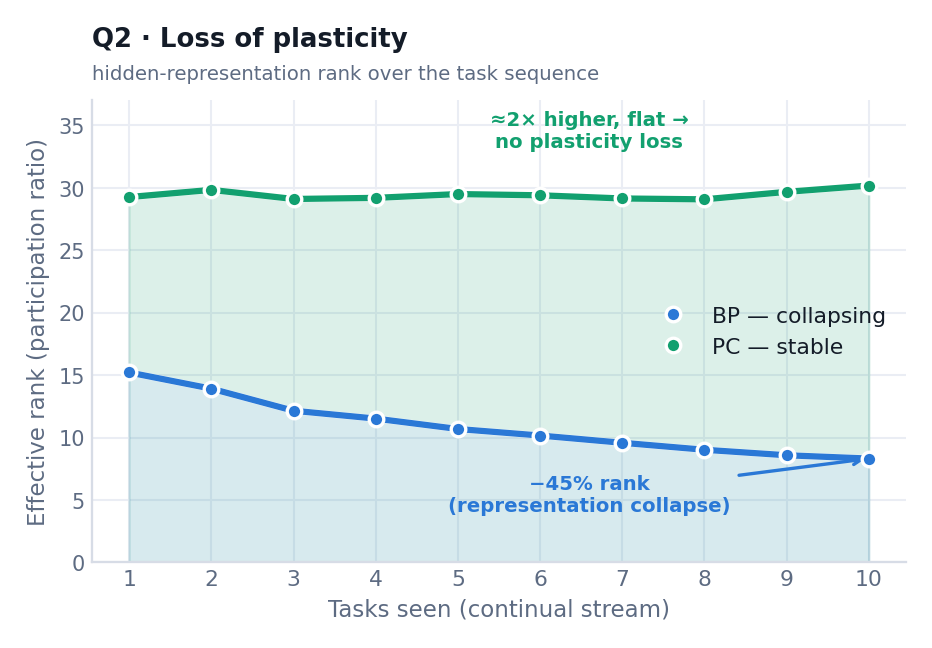<br><sub>Q2 · effective rank (loss of plasticity)</sub>

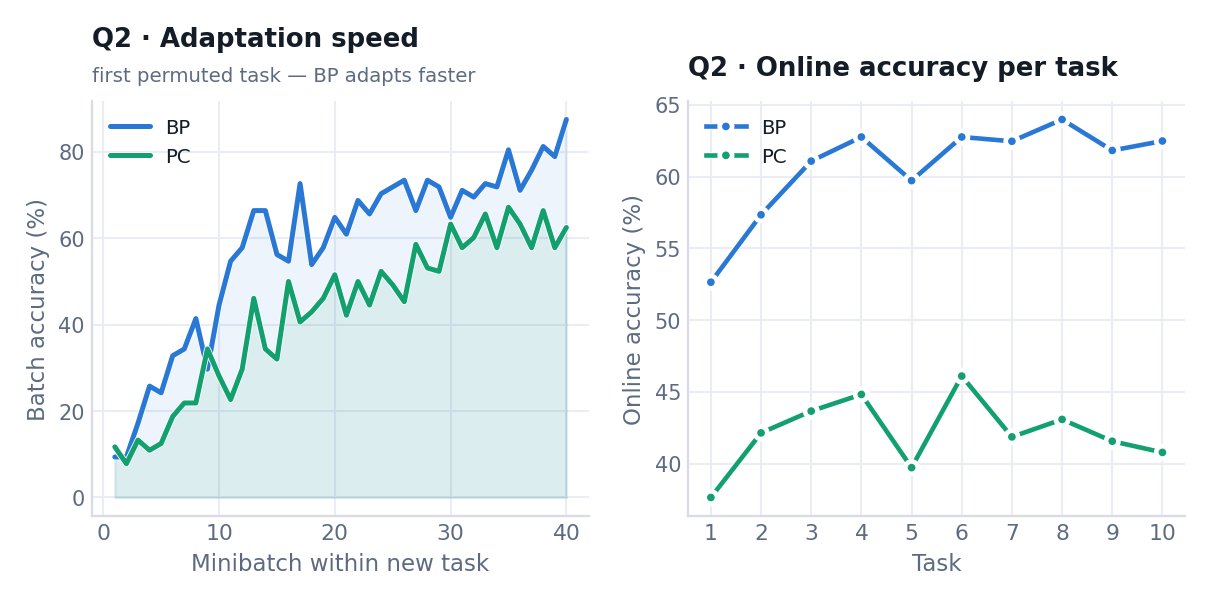<br><sub>Q2 · adaptation speed & online accuracy</sub>

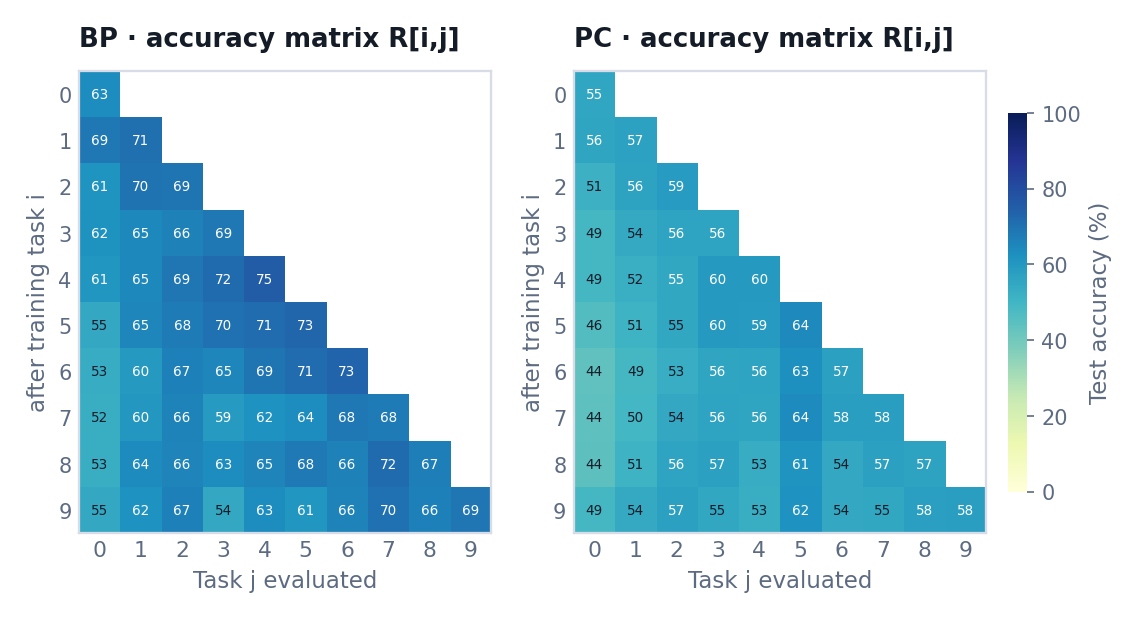<br><sub>Q2 · retention matrices R[i,j]</sub>

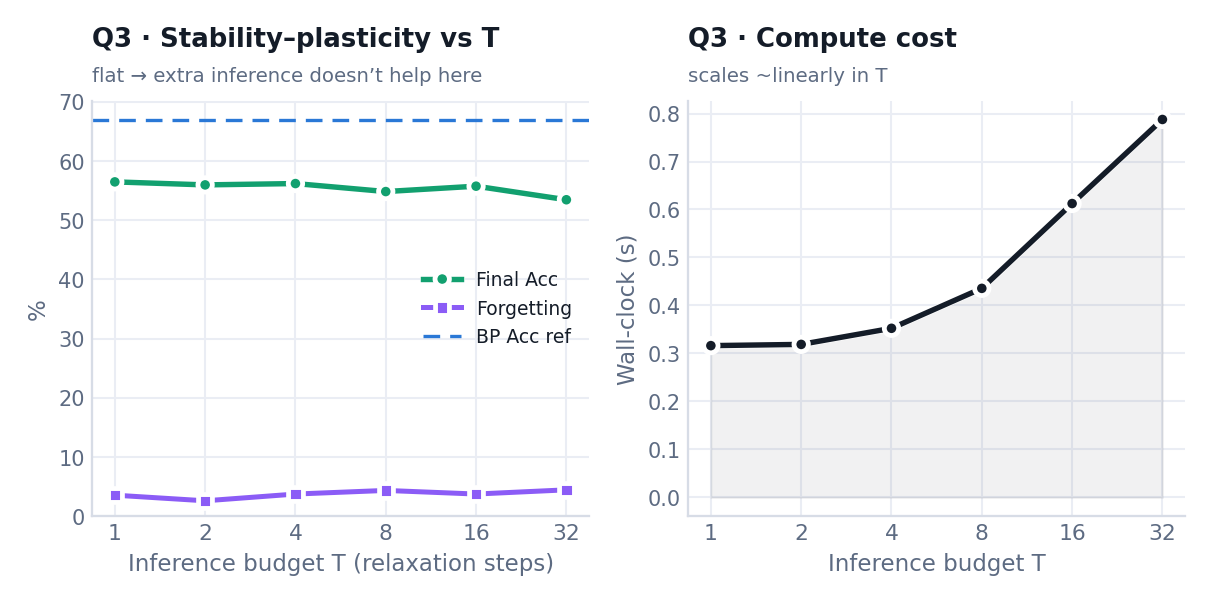<br><sub>Q3 · stability–plasticity vs inference budget T</sub>



**Read:** PC roughly **halves forgetting** (3.6% vs 8.4%) and **preserves effective rank** where backprop's collapses — the genuine *beyond-backprop* robustness. Cost: slightly lower raw accuracy under permutation.